In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("winequality-red.csv")
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [4]:
df.shape

(1599, 12)

In [5]:
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(240)

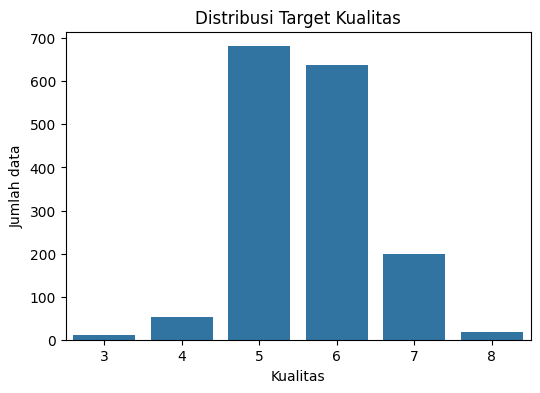

In [7]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="quality")
plt.title("Distribusi Target Kualitas")
plt.xlabel("Kualitas")
plt.ylabel("Jumlah data")
plt.show()

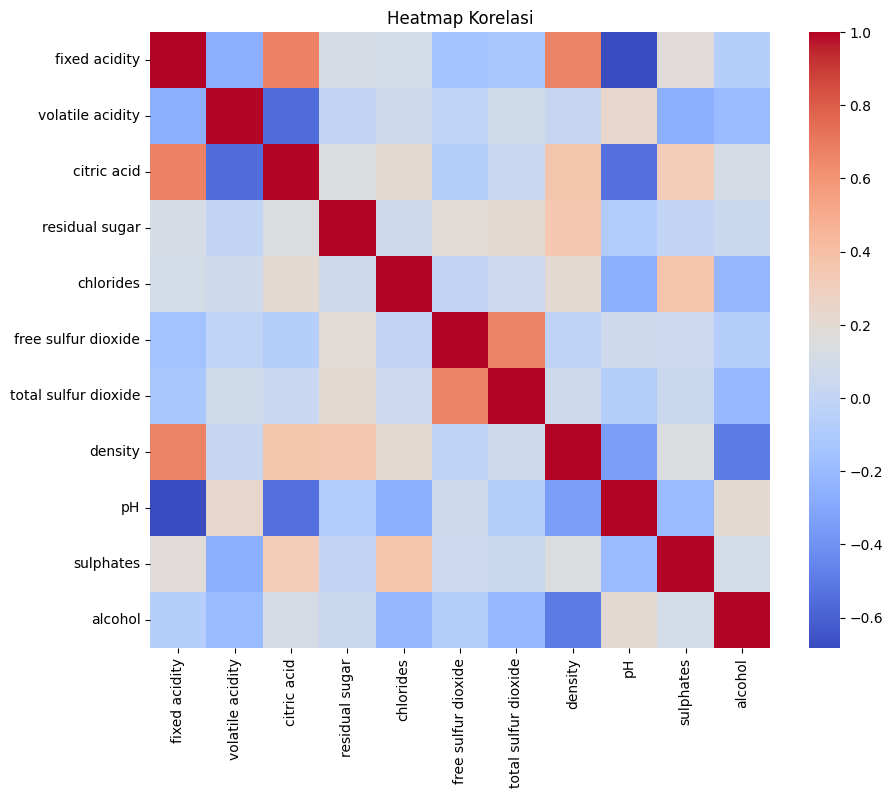

In [8]:
correlation = df.drop(columns=["quality"]).corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation, cmap="coolwarm")
plt.title("Heatmap Korelasi")
plt.show()

In [9]:
df.columns = df.columns.str.replace(' ', '_')
df['quality'] = df['quality'].apply(lambda x: 1 if x >= 6 else 0)

print("\nDistribusi kelas baru:")
print(df['quality'].value_counts())


Distribusi kelas baru:
quality
1    855
0    744
Name: count, dtype: int64


In [10]:
X = df.drop('quality', axis=1)
y = df['quality']

In [11]:
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)
df_processed = pd.concat([X_scaled, y], axis=1)

In [12]:
df_processed.to_csv('winequality_preprocessing.csv', index=False)
print("Data preprocessing berhasil disimpan!")

Data preprocessing berhasil disimpan!
